## **Exercise 06 : Scatter Matrix**

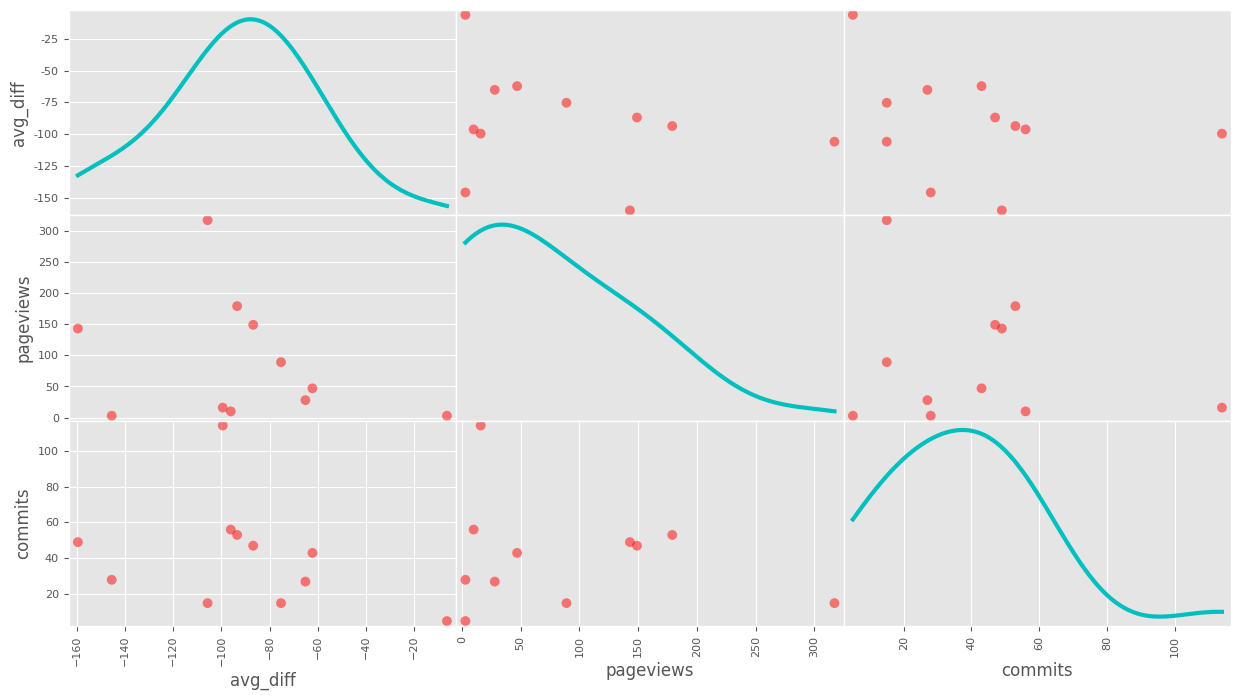

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import scipy

connection = sqlite3.connect('../data/checking-logs.sqlite')
views_diff = pd.read_sql('\
                with avg_diff as \
                (with test_to_join as \
                (select uid, labname, first_commit_ts from test group by uid, labname)\
                \
                select uid, avg(strftime("%s", first_commit_ts) - deadlines)/ (60*60) as avg_diff  \
                from test_to_join left join deadlines on test_to_join.labname = deadlines.labs \
                where labname like "%laba%" group by uid),\
                \
                newsfeed as (select uid, count(datetime) as pageviews from pageviews group by uid),\
                \
                commits as (select uid, count(timestamp) as commits from checker where labname like "%laba%" group by uid)\
                \
                select uid, avg_diff, pageviews, commits from avg_diff left join newsfeed using(uid) left join commits using(uid)', connection)

plt.style.use('ggplot')
pd.plotting.scatter_matrix(views_diff, figsize=(15, 8), diagonal='kde', marker=".", s=200, color='red')
for ax in plt.gcf().axes:
        for line in ax.get_lines():
            line.set_color('c')
            line.set_lw(3)
plt.show()

In [2]:
connection.close()

matrix(0: [0,1,2], 1: [0,1,2], 2: [0,1,2])  avg_diff x avg_diff - 0,0
1. Q: Can we say that if a user has a low number of pageviews then they likely have a low number of commits?  
A: NO (2,1)

3. Q: Can we say that if a user has a low number of pageviews then they likely have a small average difference 
between the first commit and the lab deadline?”  
A: NO (0, 1)

5. Q: Can we say that there are many users with a low number of commits and a few with a high number of commits”?  
A: YES (2, 2)

7. Q: Can we say that there are many users with a small average difference and a few with a large average difference”?  
A: NO (0, 0 - almost normal distribution)